In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from coleta import customers, order_payments, orders

### Gerando o dataset de pedidos associando aos seus respectivos estados

In [3]:
pedidos_estados = orders.merge(customers, on='customer_id').merge(order_payments, on='order_id')

### Limpando valores nulos em 'order_delivered_customer_date' pois será analisado apenas pedidos entregues.

In [4]:
pedidos_estados.dropna(subset='order_delivered_customer_date', inplace=True)

### Passando todas colunas do tipo object para string

In [5]:
colunas_object = pedidos_estados.select_dtypes(include='object').columns

pedidos_estados[colunas_object] = pedidos_estados[colunas_object].astype('string')

- Primeira pergunta de negócio: Quais estados possuem maior quantidade de pedidos?

In [6]:
contagem_pedidos_estados = pedidos_estados.groupby('customer_state').agg(quantidade=('order_id', 'count')).sort_values(by='quantidade', ascending=False).reset_index()

In [7]:
contagem_pedidos_estados.rename(columns={'customer_state': 'estado'}, inplace=True)

In [8]:
contagem_pedidos_estados.head(10)

,estado,quantidade
0,SP,42302
1,RJ,13007
2,MG,11805
3,RS,5543
4,PR,5129
5,SC,3662
6,BA,3483
7,DF,2142
8,ES,2068
9,GO,2047


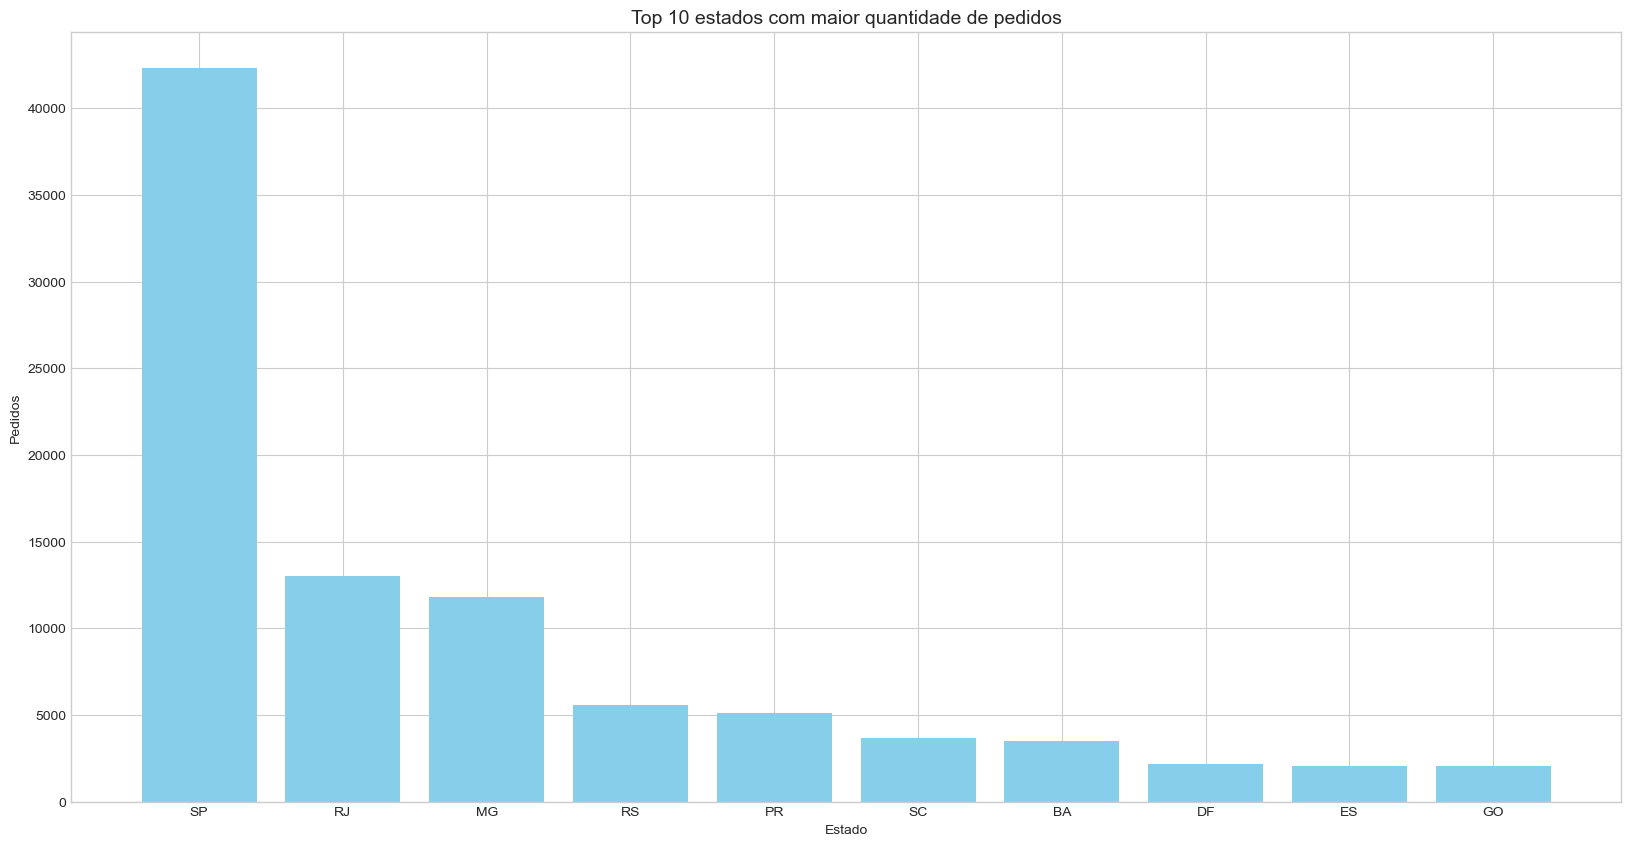

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(20, 10))
plt.bar(contagem_pedidos_estados['estado'].head(10), contagem_pedidos_estados['quantidade'].head(10), color='skyblue')
plt.title('Top 10 estados com maior quantidade de pedidos', fontsize=14)
plt.xlabel('Estado')
plt.ylabel('Pedidos')
plt.show()

- Segunda pergunta de negócio: Quais estados geram maior faturamento?

In [10]:
faturamento_estados = pedidos_estados.groupby('customer_state').agg(Faturamento_Total=('payment_value', 'sum')).sort_values(by='Faturamento_Total', ascending=False).reset_index()

In [11]:
faturamento_estados.head(10)

,customer_state,Faturamento_Total
0,SP,5769221.49
1,RJ,2056101.21
2,MG,1819321.70
3,RS,861608.40
4,PR,781919.55
5,SC,595361.91
6,BA,591270.60
7,DF,346146.17
8,GO,334294.22
9,ES,317682.65


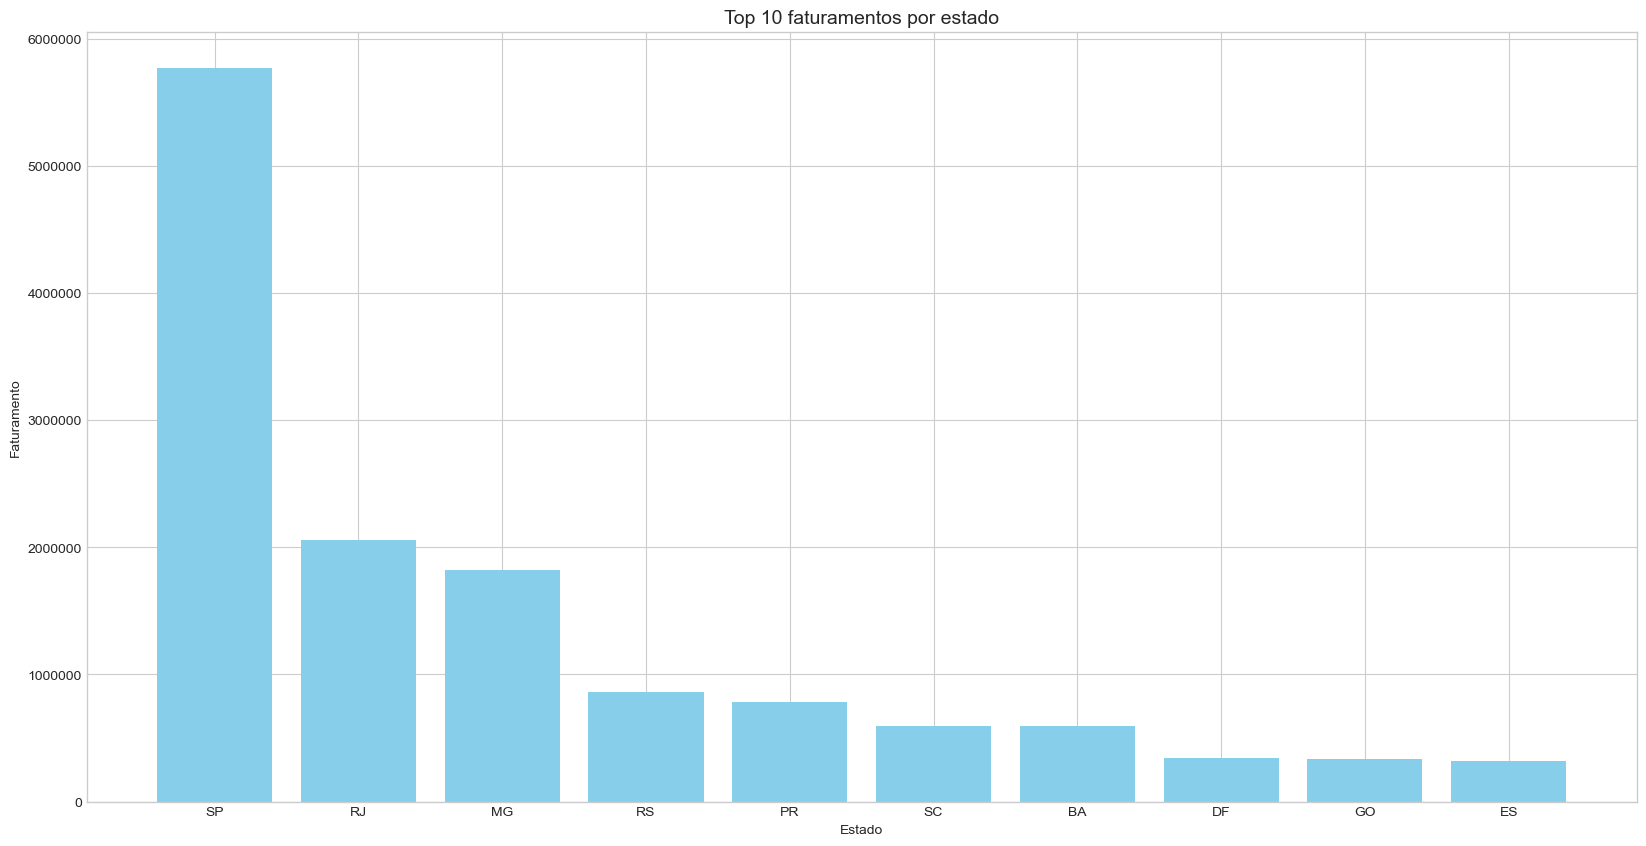

In [12]:
plt.figure(figsize=(20, 10))
plt.bar(faturamento_estados['customer_state'].head(10), faturamento_estados['Faturamento_Total'].head(10), color='skyblue')
plt.xlabel('Estado')
plt.ylabel('Faturamento')
plt.title('Top 10 faturamentos por estado', fontsize=14)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

- Terceira pergunta de negócio: O estado que possui mais pedidos é necessariamente o que gera mais receita?

In [13]:
quantidade_pedidos_faturamento = pedidos_estados.groupby('customer_state').agg(quantidade_pedidos=('order_id', 'count'), faturamento=('payment_value', 'sum')).reset_index()

In [14]:
quantidade_pedidos_faturamento.sort_values(by='quantidade_pedidos', ascending=False).head(10)

,customer_state,quantidade_pedidos,faturamento
25,SP,42302,5769221.49
18,RJ,13007,2056101.21
10,MG,11805,1819321.70
22,RS,5543,861608.40
17,PR,5129,781919.55
23,SC,3662,595361.91
4,BA,3483,591270.60
6,DF,2142,346146.17
7,ES,2068,317682.65
8,GO,2047,334294.22


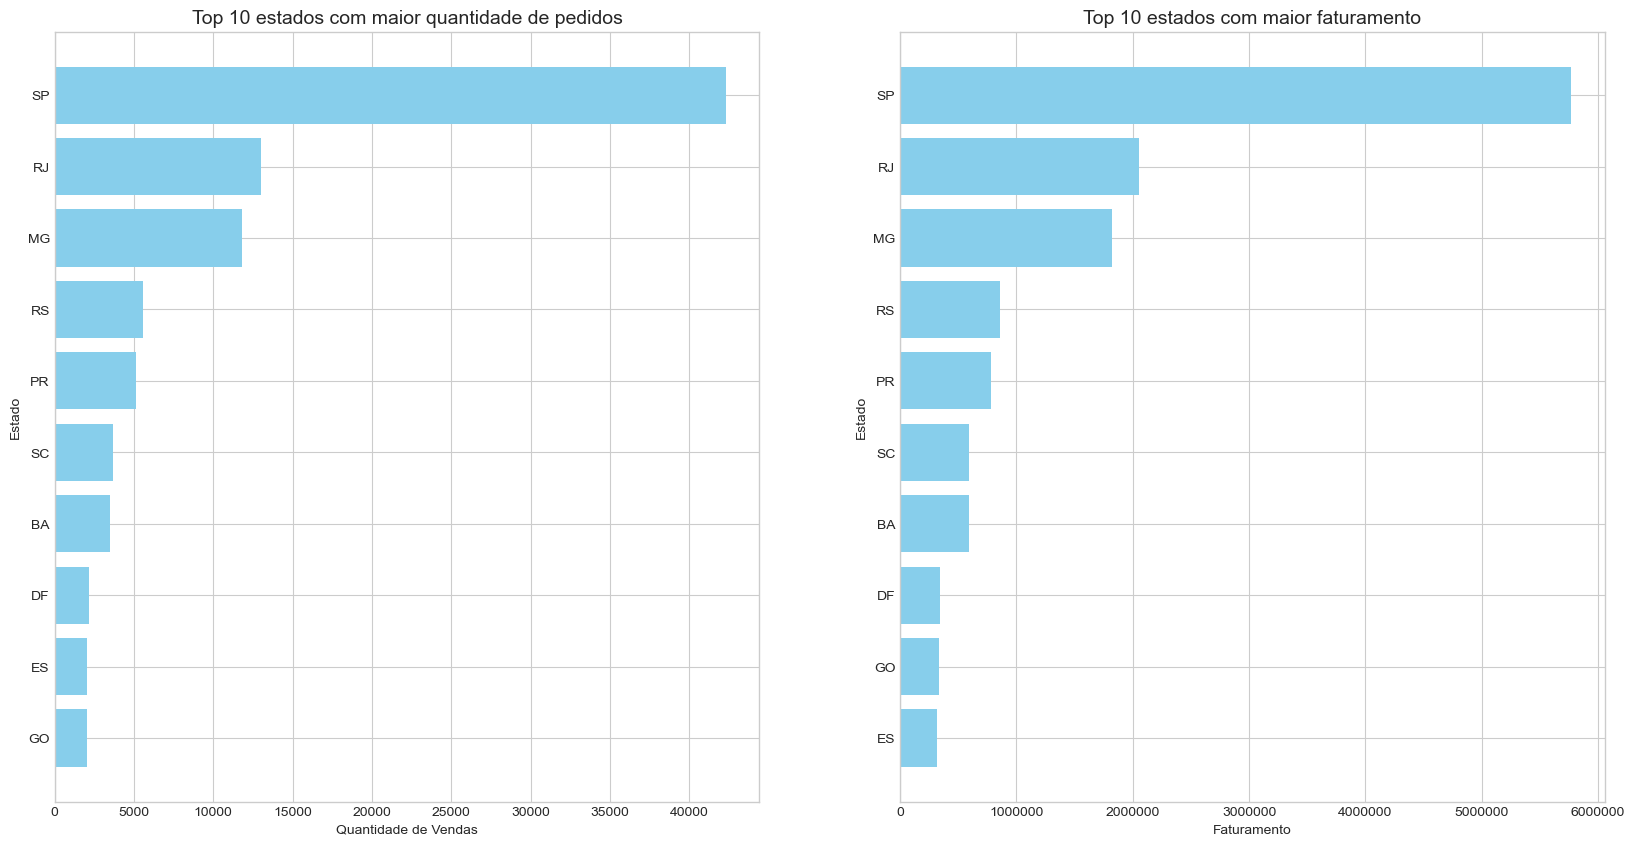

In [15]:
fig, (graf_esq, graf_dir) = plt.subplots(1, 2, figsize=(20, 10))
graf_esq.barh(quantidade_pedidos_faturamento.sort_values(by='quantidade_pedidos', ascending=False)['customer_state'].head(10), quantidade_pedidos_faturamento.sort_values(by='quantidade_pedidos', ascending=False)['quantidade_pedidos'].head(10), color='skyblue')
graf_esq.set_ylabel('Estado')
graf_esq.set_xlabel('Quantidade de Vendas')
graf_esq.set_title('Top 10 estados com maior quantidade de pedidos', fontsize=14)
graf_esq.invert_yaxis()
graf_dir.barh(quantidade_pedidos_faturamento.sort_values(by='faturamento', ascending=False)['customer_state'].head(10), quantidade_pedidos_faturamento.sort_values(by='faturamento', ascending=False)['faturamento'].head(10), color='skyblue')
graf_dir.set_ylabel('Estado')
graf_dir.set_xlabel('Faturamento')
graf_dir.set_title('Top 10 estados com maior faturamento', fontsize=14)
graf_dir.ticklabel_format(style='plain', axis='x')
graf_dir.invert_yaxis()
plt.show()

    O Estado que possui mais pedidos é São Paulo, e também é o que mais gerou receita. Então sim, o estado que mais vendeu também é o que gerou mais receita.

- Quarta pergunta de negócio: Existem estados com participação muito baixa nas vendas que poderiam representar oportunidades de crescimento?

In [16]:
ticket_medio_estados_menos_participacao = pd.DataFrame()

In [17]:
total_estados = quantidade_pedidos_faturamento['customer_state'].count()
qtd_estados_fora_do_top_10 = total_estados - 10

In [18]:
ticket_medio_estados_menos_participacao['estado'] = quantidade_pedidos_faturamento.sort_values(by='faturamento', ascending=False)['customer_state'].tail(qtd_estados_fora_do_top_10)
ticket_medio_estados_menos_participacao['ticket_medio'] = quantidade_pedidos_faturamento.sort_values(by='faturamento', ascending=False)['faturamento'].tail(qtd_estados_fora_do_top_10) / quantidade_pedidos_faturamento.sort_values(by='faturamento', ascending=False)['quantidade_pedidos'].tail(qtd_estados_fora_do_top_10)

In [19]:
ticket_medio_estados_menos_participacao = ticket_medio_estados_menos_participacao.sort_values(by='ticket_medio', ascending=False)

In [20]:
ticket_medio_estados_menos_participacao.head(10)

,estado,ticket_medio
14,PB,250.153630
0,AC,235.978916
3,AP,233.939275
1,AL,229.186837
20,RO,226.994821
21,RR,220.476098
13,PA,216.134098
16,PI,208.873353
24,SE,204.328866
26,TO,203.414814


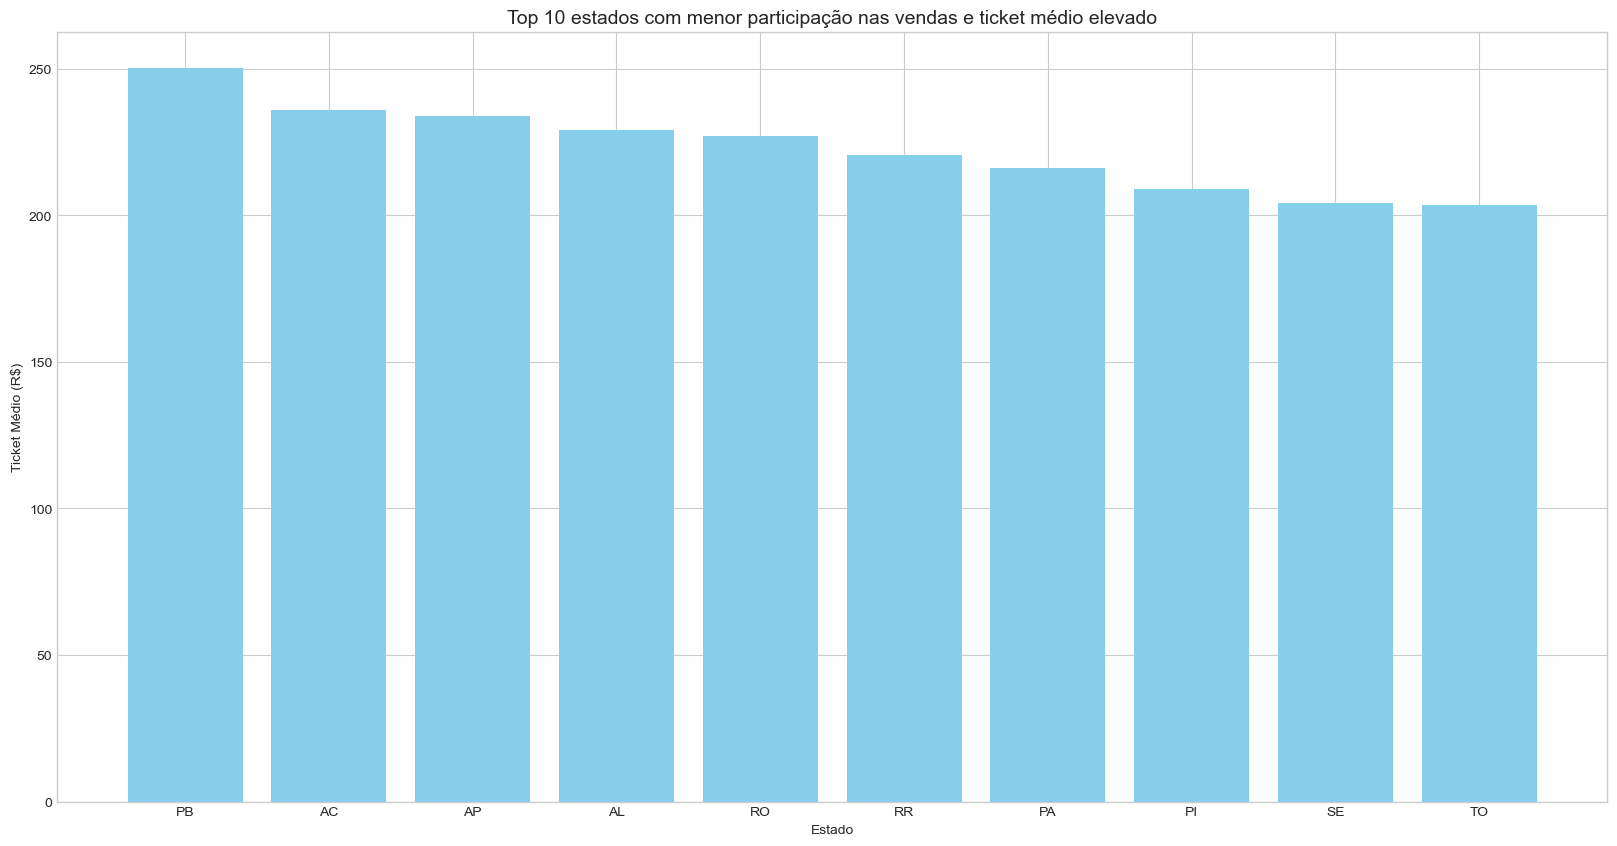

In [21]:
plt.figure(figsize=(20, 10))
plt.bar(ticket_medio_estados_menos_participacao['estado'].head(10), ticket_medio_estados_menos_participacao['ticket_medio'].head(10), color='skyblue')
plt.xlabel('Estado')
plt.ylabel('Ticket Médio (R$)')
plt.title('Top 10 estados com menor participação nas vendas e ticket médio elevado', fontsize=14)
plt.show()

    Sim, existem estados com participações baixas mas que apresentam oportunidades de crescimento. Um exemplo são os estados PB, AC e AP que apesar de apresentarem um faturamento menor, tem um ticket médio superior aos outros estados. Esses estados apresentam baixo volume de vendas combinado a ticket médio relativamente elevado, o que pode indicar uma oportunidade a ser investigada